Markov Chain Monte Carlo (MCMC) example

Linar mass action model

Alexander Johnston Queensland University of Technology a44.johnston@qut.edu.au

In [56]:
using Plots, DelimitedFiles, DifferentialEquations, SparseArrays, Interpolations, Random, Distributions, NLopt, Dierckx, LaTeXStrings, BSplineKit, Plots.PlotMeasures, LinearAlgebra
gr()

plot_font = "Computer Modern"
default(fontfamily=plot_font,linewidth=1,framestyle=:box,label=nothing,grid=true)

#Model parameters
r1 = 0.3;
r2 = 0.5;
c1_0 = 1;
c2_0 = 0;

alpha = r1;
beta = r2;

a = [alpha, beta];

#Initial conditions
x0 = c1_0;
y0 = c2_0;

#Number of synthetic data points
N_data = 21;

t_start = 0;
t_end = 10;
tt = LinRange(t_start, t_end, N_data);

t = tt;

#Standard deviation of additive Gaussian noise used to generate the synthetic data
sigma=0.02; 



Creating synthetic data sets.

In [57]:
#Create synthetic data for the linear mass action model.

function Mass_Action(t,r1,r2,c1_0,c2_0)
    c1 = [];
    c2 = [];
    for i in 1:length(t) 
        if r1 != r2
            c1_t_i = c1_0*exp(-r1*t[i])
            c2_t_i = c1_0*exp(-r1*t[i])*(r1/(r2-r1)) + (c2_0 - c1_0*r1/(r2 - r1))*exp(-r2*t[i])
        else
            c1_t_i = c1_0*exp(-r1*t[i])
            c2_t_i = c1_0*exp(-r1*t[i])*(r1*t[i] + c2_0/c1_0)    
        end
        
        c1 = vcat(c1, c1_t_i);
        c2 = vcat(c2, c2_t_i);
        
    end
    
return [c1, c2]
end
 
ic=[x0, y0]
sol = Mass_Action(t,r1,r2,c1_0,c2_0)
x_true = sol[1];
y_true = sol[2];

#Create stochastic data using additive Gaussian noise applied at each data point for the true solution

dist=Normal(0,sigma);

x_data_sample = zeros(length(x_true));
y_data_sample = zeros(length(y_true));

for (i, x_model_i) in enumerate(x_true)
    x_data_sample[i] = x_model_i + rand(dist)
end

for (i, y_model_i) in enumerate(y_true)
    y_data_sample[i] = y_model_i + rand(dist)
end

t_data = t;   

xy_data_sample = vcat(x_data_sample, y_data_sample);


MCMC Procedure

In this section, we set up the hyperparameters for the MCMC algorithm, and then conduct inference with MCMC.

In [58]:
#Hyperparameters
h = 0.001; #Step size in parameter space
N_iter = 100000; #Number of iterations in MCMC trace
b_in = 20000; #Burn-in iterations

In [59]:
#MCMC Procedure
t1 = time();

dist_normal = Normal(0,sigma);

#Initial parameter values
alpha_start = 1.1; 
delta_start = 0.9;

alpha_list = [alpha_start];
delta_list = [delta_start];

alpha_i = alpha_start; 
delta_i = delta_start;

x_test = Mass_Action(tt,alpha_i,delta_i,c1_0,c2_0)[1]
y_test = Mass_Action(tt,alpha_i,delta_i,c1_0,c2_0)[2]

xy_test = vcat(x_test, y_test);

l_i = loglikelihood(dist_normal, (xy_data_sample - xy_test));

likelihood_list = [l_i];

for i in range(1, N_iter);

    a_i = vcat(alpha_i, delta_i);
    x_test = Mass_Action(tt,alpha_i,delta_i,c1_0,c2_0)[1]
    y_test = Mass_Action(tt,alpha_i,delta_i,c1_0,c2_0)[2]
    xy_test = vcat(x_test, y_test);
    l_i = loglikelihood(dist_normal, (xy_data_sample - xy_test));
    
    #Transition point
    phi = rand(Uniform(0, 2*pi));
    alpha_step = h*cos(phi);
    delta_step = h*sin(phi);
    
    if alpha_i + alpha_step > 0 && delta_i + delta_step > 0
        alpha_i_test = alpha_i + alpha_step
        delta_i_test = delta_i + delta_step;
    else
        alpha_i_test = alpha_i
        delta_i_test = delta_i
    end
        
    a_i_test = vcat(alpha_i_test, delta_i_test);
    x_test = Mass_Action(tt,alpha_i,delta_i,c1_0,c2_0)[1]
    y_test = Mass_Action(tt,alpha_i,delta_i,c1_0,c2_0)[2]

    x_test_new = Mass_Action(tt,alpha_i_test,delta_i_test,c1_0,c2_0)[1]
    y_test_new = Mass_Action(tt,alpha_i_test,delta_i_test,c1_0,c2_0)[2]
    xy_test_new = vcat(x_test_new, y_test_new);

    l_i_test = loglikelihood(dist_normal, (xy_data_sample - xy_test_new));
    
    p_ratio = exp(l_i_test - l_i);
    gamma = min(1, p_ratio);
    transition_accepted = rand(Binomial(1, gamma));
    
    if transition_accepted == 1
        alpha_i = alpha_i_test;
        delta_i = delta_i_test;
    end

    alpha_list = vcat(alpha_list, alpha_i);
    delta_list = vcat(delta_list, delta_i);
    likelihood_list = vcat(likelihood_list, l_i);
end

elapsed_time = time() - t1;
println("Elapsed time: ", elapsed_time, " seconds")

Elapsed time: 14.305842876434326 seconds


We now plot histograms of parameter estimates after the burn-in period.

In [62]:
alpha_percentile_05 = quantile(vec(alpha_list), 0.05)
alpha_percentile_95 = quantile(vec(alpha_list), 0.95)

0.31434815866968613

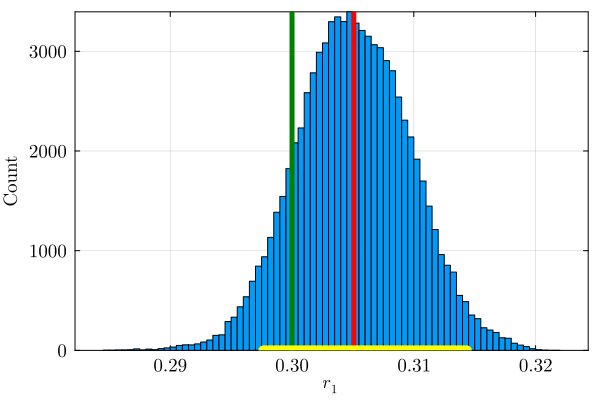

In [63]:
pha = histogram(alpha_list[b_in:N_iter], xlabel=L"r_{1}", ylabel = "Count", xguidefontsize=12, yguidefontsize=12,xtickfontsize=12, ytickfontsize=12)
pha = vline!([mean(alpha_list[b_in:N_iter])], color = :red, linewidth = 5)
pha = vline!([r1], color = :green, linewidth = 5)
pha = plot!([alpha_percentile_05; alpha_percentile_95], [0; 0], lw=10, lc=:yellow, legend=false)

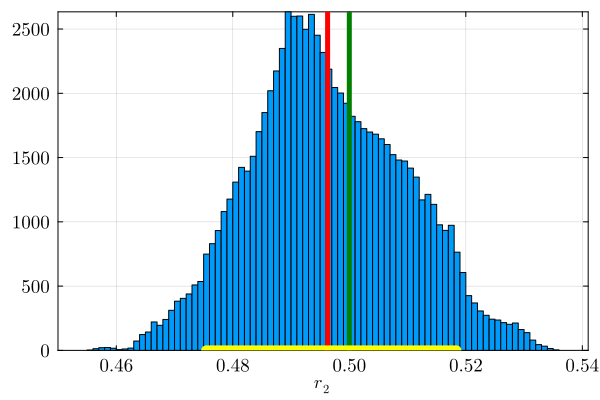

In [64]:
delta_percentile_05 = quantile(vec(delta_list[b_in:N_iter]), 0.05)
delta_percentile_95 = quantile(vec(delta_list[b_in:N_iter]), 0.95)

phd = histogram(delta_list[b_in:N_iter], xlabel=L"r_{2}", xguidefontsize=12, yguidefontsize=12,xtickfontsize=12, ytickfontsize=12)
phd = vline!([mean(delta_list[b_in:N_iter])], color = :red, linewidth = 5)
phd = vline!([r2], color = :green, linewidth = 5)
phd = plot!([delta_percentile_05; delta_percentile_95], [0; 0], lw=10, lc=:yellow, legend=false)

We then produce a contour plot of the parameter estimates after the burn-in period.

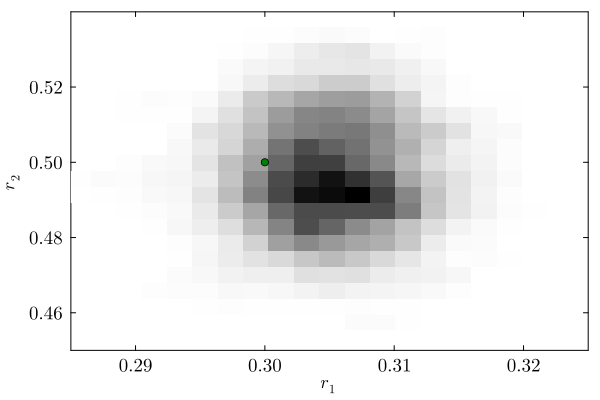

In [65]:
N_alpha = 20;
N_delta = 20;

alpha_min = minimum(alpha_list[b_in:N_iter]);
delta_min = minimum(delta_list[b_in:N_iter]);

alpha_max = maximum(alpha_list[b_in:N_iter]);
delta_max = maximum(delta_list[b_in:N_iter]);

alpha_bins = LinRange(alpha_min, alpha_max, N_alpha);
delta_bins = LinRange(delta_min, delta_max, N_delta);

pc = histogram2d(alpha_list[b_in:N_iter], delta_list[b_in:N_iter], xlims = (0.285, 0.325), ylims = (0.45, 0.54), grid = false, colorbar = false, c=:binary, bins = (alpha_bins, delta_bins), xlabel=L"r_{1}", ylabel=L"r_{2}", xguidefontsize=12, yguidefontsize=12,xtickfontsize=12, ytickfontsize=12)
pc2 = scatter!([r1], [r2], color = :green)


Final plot containing the MCMC results.

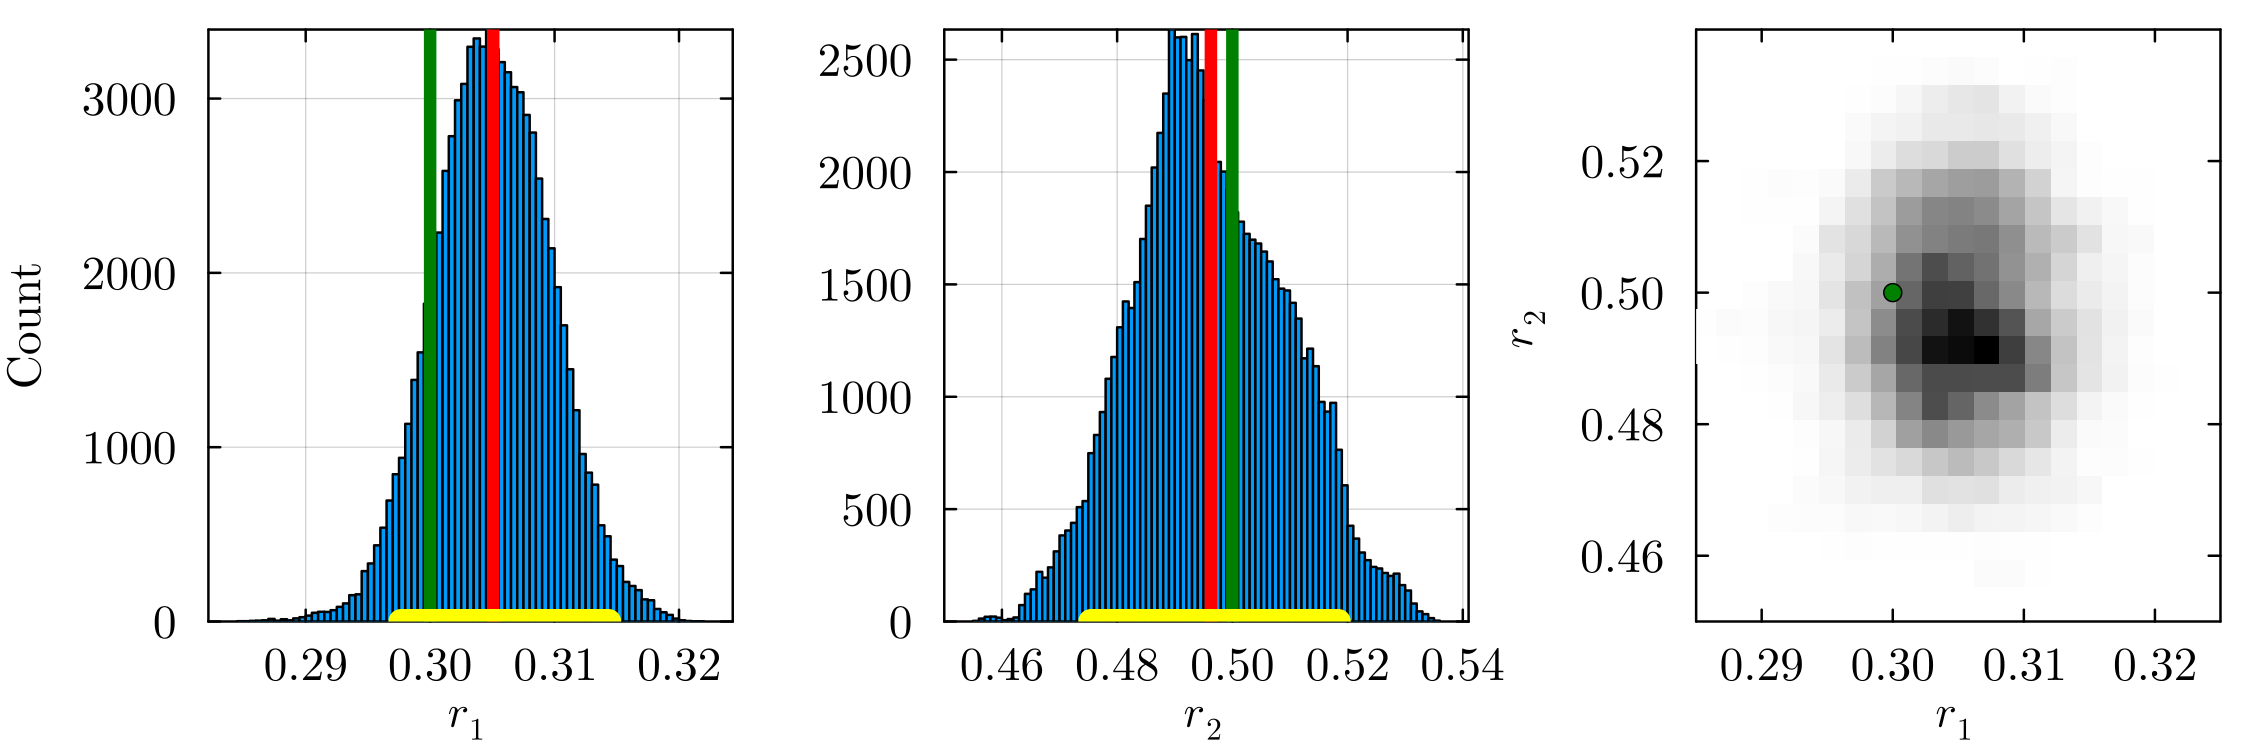

In [66]:
MCMC_plot = plot(pha, phd, pc, layout = grid(1, 3), size = (900, 300), dpi = 250, bottom_margin=5mm, left_margin=4mm)